In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt


In [11]:
df=pd.read_csv('Algerian_forest_fires_clean_dataset.csv')

In [12]:
df['FWI']=df.pop('FWI')

In [13]:
df

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region,FWI
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,1,0,0.5
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,1,0,0.4
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,1,0,0.1
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,1,0,0.0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,1,0,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,0,1,6.5
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,1,1,0.0
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,1,1,0.2
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,1,1,0.7


In [14]:
X=df.iloc[:,:-1]
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,1,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,1,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,1,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,1,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,1,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,0,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,1,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,1,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,1,1


In [15]:
y=df.iloc[:,-1]
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [17]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

<Axes: >

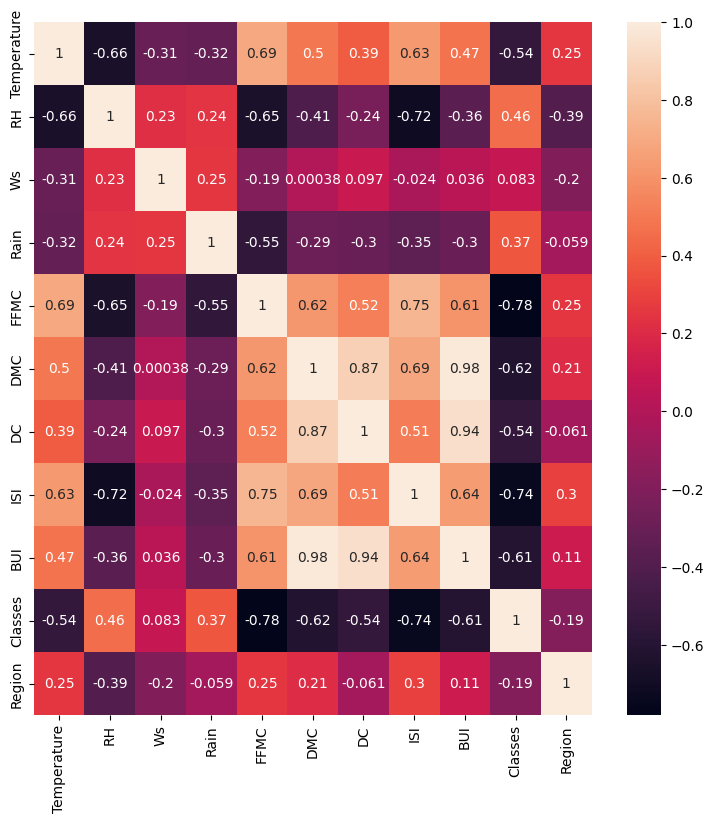

In [18]:
plt.figure(figsize=(9,9))
sns.heatmap(X_train.corr(),annot=True)

In [19]:
# now we will find the feature which are highly corelated
def correllation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]>threshold):
                col_name=corr_matrix.columns[i]
                col_corr.add(col_name)

    return col_corr

In [21]:
corr_features=correllation(X_train,0.85)
print(corr_features)

{'BUI', 'DC'}


In [22]:
## droppng feature that are highly correlated 
X_train.drop(corr_features,axis=1,inplace=True)

In [23]:
X_test.drop(corr_features,axis=1,inplace=True)

In [24]:
X_train.shape,X_test.shape

((182, 9), (61, 9))

In [25]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

In [26]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
         1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
         1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
        -0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
         1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
        -0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
         1.10431526, -0.98907071]])

<Axes: title={'center': 'X_train after the scaling'}>

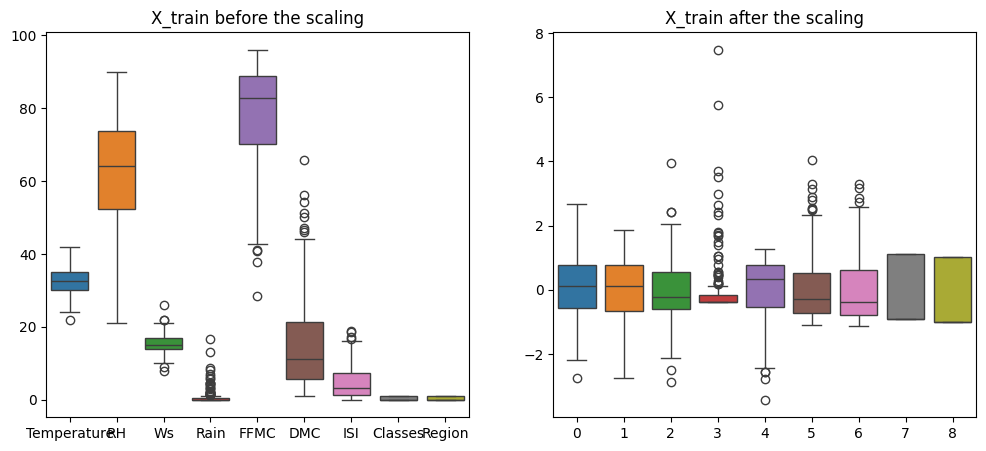

In [27]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("X_train before the scaling")
sns.boxplot(X_train)
plt.subplot(1,2,2)
plt.title("X_train after the scaling")
sns.boxplot(X_train_scaled)

## Linear regrresion

In [28]:
from sklearn.linear_model import LinearRegression
linrig=LinearRegression()
linrig.fit(X_train_scaled,y_train)

LinearRegression()

In [29]:
y_pred=linrig.predict(X_test_scaled)

In [30]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.6742766873791587
0.5468236465249982
0.8211435242265256


In [31]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
score

0.9847657384266951

In [32]:
adjusted_r2 = 1 - ((1 - score) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1))
adjusted_r2

0.9820773393255237

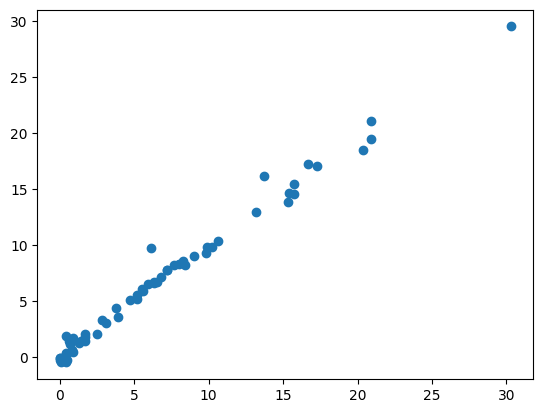

In [33]:
plt.scatter(y_test,y_pred)

## lasso Regression

MSE -> 2.2483458918974764
MAE -> 1.133175994914409
RSME -> 1.4994485292591662
R_square_score -> 0.9492020263112388
Adujusted_R_square_score -> 0.9402376780132222


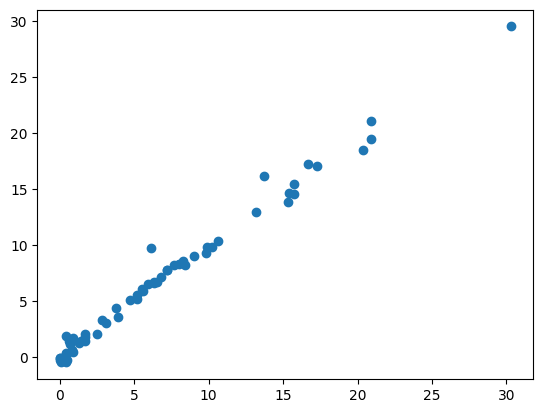

In [34]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred1=lasso.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred1)
mae=mean_absolute_error(y_test,y_pred1)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred1)
score
adjusted_r2 = 1 - ((1 - score) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1))
adjusted_r2
print("MSE ->",mse)
print("MAE ->",mae)
print("RSME ->",rmse)
print("R_square_score ->",score)
print("Adujusted_R_square_score ->",adjusted_r2)
plt.scatter(y_test,y_pred)

### Ridge regression

MSE -> 0.6949198918152096
MAE -> 0.5642305340105713
RSME -> 0.8336185529456561
R_square_score -> 0.9842993364555512
Adujusted_R_square_score -> 0.9815286311241779


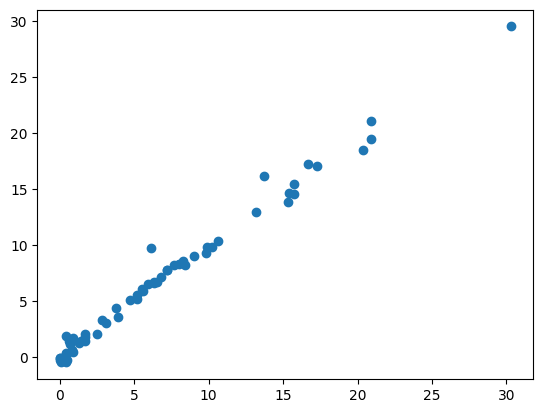

In [38]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred2=ridge.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred2)
mae=mean_absolute_error(y_test,y_pred2)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred2)
score
adjusted_r2 = 1 - ((1 - score) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1))
adjusted_r2
print("MSE ->",mse)
print("MAE ->",mae)
print("RSME ->",rmse)
print("R_square_score ->",score)
print("Adujusted_R_square_score ->",adjusted_r2)
plt.scatter(y_test,y_pred)

## Elastic_net

MSE -> 5.517251101025224
MAE -> 1.8822353634896
RSME -> 2.3488829474933874
R_square_score -> 0.8753460589519703
Adujusted_R_square_score -> 0.8533483046493768


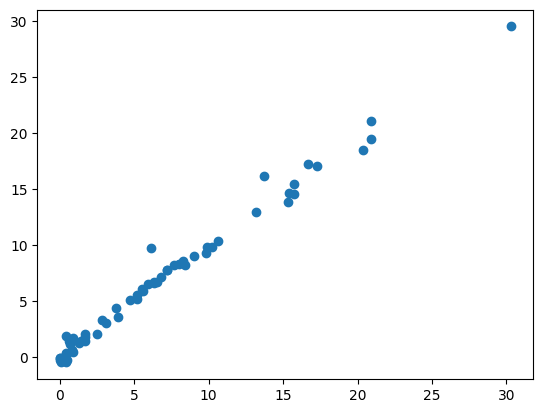

In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred3=elastic.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred3)
mae=mean_absolute_error(y_test,y_pred3)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred3)
score
adjusted_r2 = 1 - ((1 - score) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1))
adjusted_r2
print("MSE ->",mse)
print("MAE ->",mae)
print("RSME ->",rmse)
print("R_square_score ->",score)
print("Adujusted_R_square_score ->",adjusted_r2)
plt.scatter(y_test,y_pred)

In [39]:
import pickle
pickle.dump(scalar,open('scalar.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))

In [45]:
a=pickle.load(open('/Users/barunwason/python/ridge_lasso/ridge.pkl','rb'))

In [46]:
a

Ridge()